**Note:**  
This notebook expects the raw dataset at `../data/fraud_data_raw.csv`.  
Create a `data/` folder in the project root and place the raw dataset there before running the notebook.

# Exploratory Data Analysis (EDA)

**Project:** Financial Fraud Detection  

**Goal:**  
- Load and understand the synthetic bank transaction dataset  
- Explore fraud distribution and class imbalance  
- Identify relationships between features and the 'isFraud' target  
- Generate hypotheses to guide preprocessing and modeling

In [15]:
#Import packages and Settings 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [16]:
#Load Dataset - taking the transaction dataset from the data/ folder

df = pd.read_csv("../data/fraud_data_raw.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [17]:
df.shape, df.columns

((6362620, 11),
 Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
        'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
        'isFlaggedFraud'],
       dtype='str'))

In [18]:
#Inspecting data types, non-null counts, and statistical summaries

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [19]:
df.describe(include="all")

#we want to include all numeric and non numeric columns 

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C2098525306,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


In [31]:
#Checking for missing values in the dataset. Very rare in this type of dataset, but still worth checking.

df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [22]:
fraud_counts = df["isFraud"].value_counts()
fraud_percent = df["isFraud"].mean() * 100

print("Fraud counts:\n", fraud_counts)
print(f"\nFraud percentage: {fraud_percent:.6f}%")

Fraud counts:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage: 0.129082%


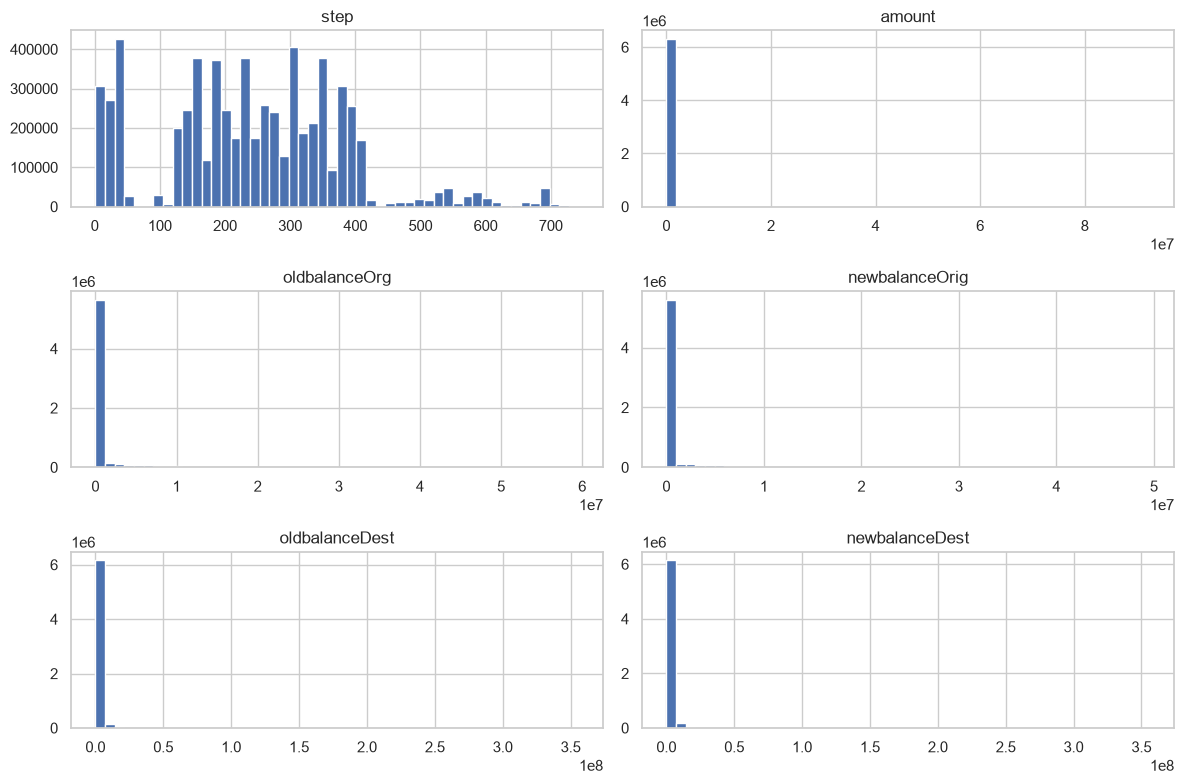

In [23]:
# Univariate analysis — numeric features

#We explore distributions of key numeric variables.  
#These columns are heavily skewed, with many zeros and extremely large outliers — typical of financial data.
#Numeric columns examined:'step', 'amount' ,'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'

numeric_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

df[numeric_cols].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

*Interpretation of Numeric Distributions*

**Step:**  
Most transactions happen between steps 0–400. This just means most activity in the dataset occurs in the earlier hours of the simulation.

**Amount:**  
Almost all transactions involve small amounts, but there are a few extremely large ones. This creates a long tail — most values near zero, a tiny number way out to the right.

**Old Balance (Origin):**  
Most sending accounts start with very little money (often zero). A small number of accounts have very large balances, which is why the graph stretches so far to the right.

**New Balance (Origin):**  
Same pattern — most accounts end with zero or close to zero after the transaction, while a smaller number retain much larger balances.

**Old Balance (Destination):**  
Most receiving accounts also start with zero. A few accounts receive very large amounts, creating another long tail.

**New Balance (Destination):**  
Again, most accounts end with small balances, but some spike to very high values after receiving money.

**Overall takeaway:**  
All of these features are extremely skewed — lots of tiny values and a few huge ones. This helps explain why fraud often involves sudden, dramatic balance changes.

Transaction type counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


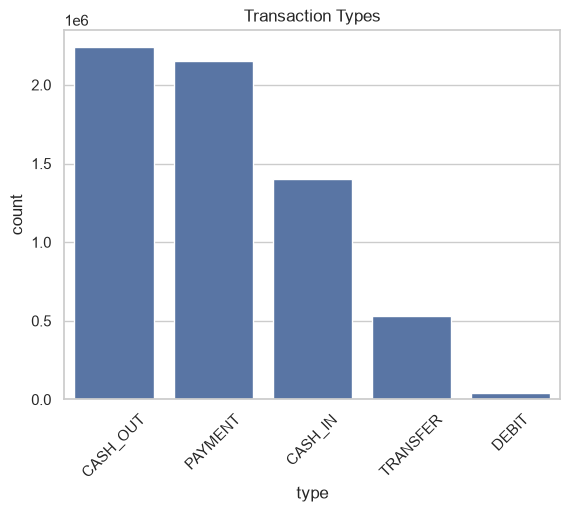

In [ ]:
#Univariate Analysis — Categorical Features
print("Transaction type counts:")
print(df["type"].value_counts())

sns.countplot(x="type", data=df, order=df["type"].value_counts().index)
plt.title("Transaction Types")
plt.xticks(rotation=45)
plt.show()

In [33]:
print("\nisFlaggedFraud counts:")
print(df["isFlaggedFraud"].value_counts())



isFlaggedFraud counts:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


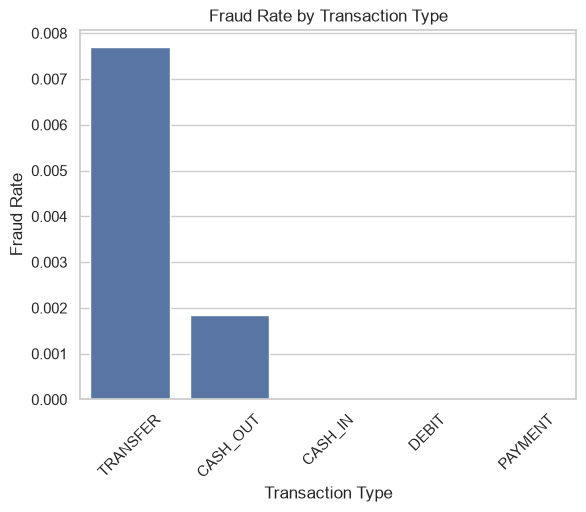

In [26]:
#Bivariate analysis — "type" vs "isFraud"
##Fraud is known to be concentrated in specific transaction types  
##(e.g., **TRANSFER** and **CASH_OUT**).  
##We compute fraud rates by type.

#Fraud rates by Type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
print(fraud_by_type)

sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values)
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

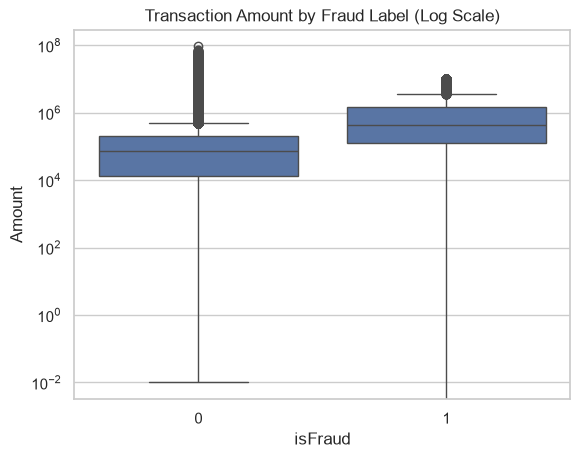

In [35]:
#Bivariate analysis — amount vs isFraud
#We compare transaction amounts for fraudulent vs non-fraudulent transaction to answer the question - Do fraudulent transactions to involve larger amounts?

sns.boxplot(x="isFraud", y="amount", data=df)
plt.yscale("log")
plt.title("Transaction Amount by Fraud Label (Log Scale)")
plt.xlabel("isFraud")
plt.ylabel("Amount")
plt.show()

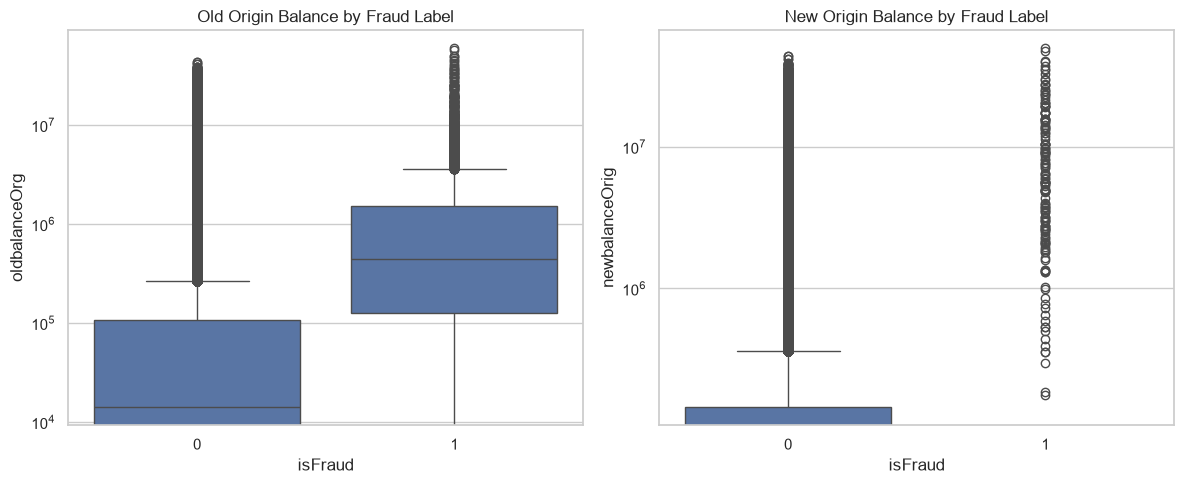

In [ ]:
#Bivariate Analysis - Balance Behavior v. Fraud

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="isFraud", y="oldbalanceOrg", data=df, ax=axes[0])
axes[0].set_title("Old Origin Balance by Fraud Label")
axes[0].set_yscale("log")

sns.boxplot(x="isFraud", y="newbalanceOrig", data=df, ax=axes[1])
axes[1].set_title("New Origin Balance by Fraud Label")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

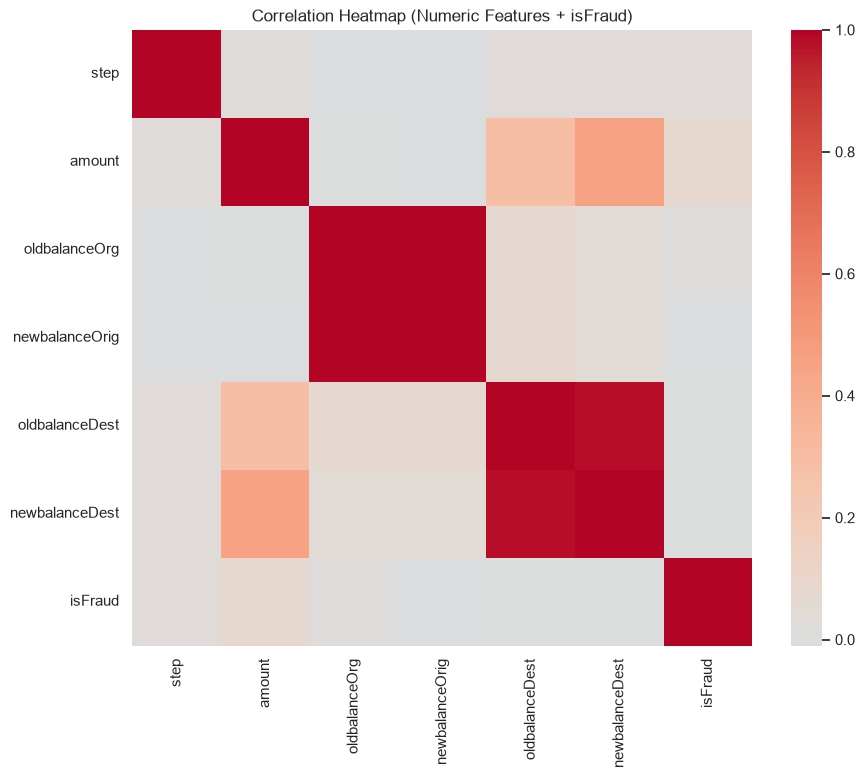

In [30]:
#Multivariate analysis — correlation between numeric features

#We compute a correlation matrix for numeric variables.  
#This helps identify relationships such as:balance changes vs amount, whether origin/destination balances move together, weak correlations typical of fraud datasets

corr = df[numeric_cols + ["isFraud"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features + isFraud)")
plt.show()


### What this correlation heatmap tells us:

- **Old vs new balances are strongly correlated**  
  This makes sense — the new balance is usually just the old balance minus the transaction amount.  
  These pairs behave almost like duplicates.

- **Destination balances also move together**  
  `oldbalanceDest` and `newbalanceDest` show a similar strong relationship.

- **Amount is only moderately related to balances**  
  Large transactions affect balances, but fraud does not always involve large amounts.

- **`step` has almost no correlation with anything**  
  Time of day/hour does not meaningfully predict fraud.

- **`isFraud` has weak correlations with all numeric features**  
  This is normal in fraud datasets — fraud is rare and often depends on *patterns*, not single numeric values.

### Key takeaway  
The heatmap confirms that:
- Some features are redundant (old/new balance pairs).  
- Fraud cannot be detected by simple linear relationships.  
- We will rely more on **patterns**, **transaction type**, and **balance changes** rather than raw correlations.

**Hypotheses Based on EDA**

1. **Fraud is concentrated in specific transaction types** 
   Compare fraud rates across transaction types to determine whether fraud is concentrated in particular transaction categories.

2. **Balance behavior is highly informative**  
   Fraudulent transactions often drain the origin account or show mismatched balance changes.

3. **Amount is extremely skewed**  
   Fraud does not always involve large amounts, but large outliers exist.

4. **Old/new balance pairs are redundant**  
   They are strongly correlated and may be simplified during preprocessing.

5. **`nameOrig` and `nameDest` should be dropped**  
   They are highly unique ID field characters that are not useful for the scope of this model.(no predictive value in our model).

6. **`isFlaggedFraud` is useless**  
    It flags very few transactions in this dataset and should be removed during preprocessing.

7. **Severe class imbalance**  
   Fraud is extremely rare — accuracy is not a reliable metric.